# Импорты

In [ ]:
#!pip install catboost
#!pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

In [ ]:
import optuna
from sklearn.metrics import f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_excel("/content/data_1_2.xlsx")
df.head(3)

In [ ]:
df.info()

# Предобработка данных

## Предобработка

### Мед-организация

В изначально представленном датасете поехали строчки, поэтому так можно было это легко отфильтровать

In [ ]:
obj_cols = ['shift_org_1', 'shift_reg_1', 'shift_spec_1']

df[obj_cols] = df[obj_cols].apply(
    pd.to_numeric, errors='coerce'
)

In [ ]:
df.condition_org.value_counts()[:15]

In [ ]:
bad_condition_org = ['0000']

df['condition_org'] = df['condition_org'].where(
    df['condition_org'].apply(lambda x: isinstance(x, str)),
    None
)

df.loc[df['condition_org'].isin(bad_condition_org), 'condition_org'] = np.nan

df.condition_org.value_counts()[:15]

In [ ]:
df = df.dropna(subset=['condition_org'])

In [ ]:
df.employment.unique()

In [ ]:
def rename_emp(x):
  if x == 'Средний медицинский персонал':
    return 'Средний МП'
  elif x == 'Средний медицинский персонал, не работаю с пациентами напрямую':
    return 'Средний МП, не раб. с пациентами напрямую'
  elif x == 'Врач, не работаю с пациентами напрямую':
    return 'Врач, не раб. с пациентами напрямую'
  else:
    return x


df["employment"]  = df["employment"].apply(rename_emp)
df["employment2"]  = df["employment2"].apply(rename_emp)
df.employment.value_counts()

### Пустые значения

In [ ]:
#строки с большим количеством пустот

In [ ]:
df = df.dropna(axis=1, thresh=5) #на всякий случай чищу мусорные столбцы
df.isna().agg(["sum", "mean"]).T.rename(columns={"sum": "missing_cnt", "mean": "missing_ratio"}).sort_values(by="missing_cnt", ascending=False).head(20) #смотрим пустые столбцы

In [ ]:
#смотрю пустые значения в строках
df.isna().sum(axis=1).value_counts().sort_index(ascending=False)

In [ ]:
df.info() #11076 значений

In [ ]:
cols = df.columns
cols = [x for x in cols if x != 'comments']

In [ ]:
df = df.dropna(subset=cols)

df.info() #10246 значений

### Опыт работы 😥😥😥

In [ ]:
df['exper_org'].nunique()

In [ ]:
df.exper_org.head()

In [ ]:
df['exper_org'] = df['exper_org'].replace(['nan', 'NaN'], np.nan)

In [ ]:
"3месяцев"[:3]

In [ ]:
import re

In [ ]:
repl_years = ["года", "лет", "год", "г", "г.", "полтора года"]
trash_text = ["более", "около", "мед сестра", ")", "профилакторий", ">", "менее", "много"]

def clean_years(x):
  x = str(x).lower()
  x = x.strip()

  for _ in trash_text: #текст не меняющий смысл
    x = x.replace(_, "").strip()

  if not x.isnumeric():

    if x in repl_years:
      return 1

    for word in repl_years:
      x_clean = x.replace(word, "").strip()#формат 2 года
      if x_clean.isnumeric():
        return x_clean

    if x in ['нет', 'нету', 'студент', 'месяц',  'месяца', "меньше года", "менее года", "да", "-", "...", "не", "пол года", "<1"]:
      return 0

    if len(x) == 0 or len(x) > 15:
      return 0

    if x == 'з':
      return 3

    x_split = x.split()
    if x_split[0].isnumeric():
      if len(x_split) == 6 and x_split[1] in ['л', 'г']:  #5 л 2 м 0 дн формат
        print(x)
        return x_split[0]

      elif len(x_split) == 2 and x_split[1][:3] == "мес" and int(x_split[0]) < 12: #формат 2 месяца
        return 0

      elif x_split[1][:3] in ["год", "лет"]:
        return x[0]



    if x[0].isnumeric() and (x[1:4] in ["мес", "нед"] or x[1] == "м"): #6месяцев
      return 0
    if x[:1].isnumeric() and x[2:5] in ["мес", "нед"]: #6месяцев
      return 0
    elif x[0].isnumeric() and (x[1:4] == "год" or x[1] == "г"): #1год, 4года и 2 месяца
      return x[0]

    #разбираюсь с нецелыми годами 3.5, 11.5
    for i in [3, 4]:
      if bool(re.fullmatch( r'\d+,\d+', x[:i])):
        return x[:i].split(",")[0]
      if bool(re.fullmatch( r'\d+.\d+', x[:i])):
        return x[:i].split(".")[0]

    match = re.search(r'\d+', x)
    if match:
        return int(match.group())

  return x

df["exper_org"] = df["exper_org"].apply(clean_years)

In [ ]:
df["exper_org"] = pd.to_numeric(df["exper_org"], errors="coerce").fillna(0)
df[~pd.to_numeric(df["exper_org"], errors='coerce').notna()].dropna(subset=["exper_org"])["exper_org"]

In [ ]:
df["exper"] = df["exper"].apply(clean_years)
df["exper_reg"] = df["exper_reg"].apply(clean_years)
df["exper_org"] = df["exper_org"].apply(clean_years)

In [ ]:
non_numeric = df[pd.to_numeric(df["exper"], errors="coerce").isna()]
print(non_numeric["exper"].unique())

In [ ]:
df["exper"] = pd.to_numeric(df["exper"], errors="coerce").fillna(0)

In [ ]:
non_numeric = df[pd.to_numeric(df["exper_reg"], errors="coerce").isna()]
print(non_numeric["exper_reg"].unique())

df["exper_reg"] = pd.to_numeric(df["exper_reg"], errors="coerce").fillna(0)

In [ ]:
df["exper_org"] = pd.to_numeric(df["exper_org"], errors="coerce").fillna(0)
df[~pd.to_numeric(df["exper_org"], errors='coerce').notna()].dropna(subset=["exper_org"])["exper_org"]

In [ ]:
df["exper_org"] = pd.to_numeric(df["exper_org"], errors="coerce")
df["exper_reg"] = pd.to_numeric(df["exper_reg"], errors="coerce")
df["exper"] = pd.to_numeric(df["exper"], errors="coerce")

### Категориальные признаки?

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols]

In [ ]:
non_numeric = df[pd.to_numeric(df["wage_rate"], errors="coerce").isna()]
print(non_numeric["wage_rate"].unique())

In [ ]:
df["wage_rate"].unique()

In [ ]:
df['wage_rate'] = df['wage_rate'].apply(lambda x: 4 if x == 'Более 3' else x)
df['wage_rate'] = df['wage_rate'].fillna(1)

non_numeric = df[pd.to_numeric(df["wage_rate"], errors="coerce").isna()]
print(non_numeric["wage_rate"].unique())

In [ ]:
non_numeric = df[pd.to_numeric(df["avr_work_hours"], errors="coerce").isna()]
print(non_numeric["avr_work_hours"].unique())


In [ ]:
df["avr_work_hours"] = pd.to_numeric(df["avr_work_hours"], errors="coerce")
df["wage_rate"] = pd.to_numeric(df["wage_rate"], errors="coerce")

### Возраст

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

df["age"].plot(kind="hist", bins=20, ax=axes[0])
axes[0].set_title("Age")

plt.tight_layout()
plt.show()

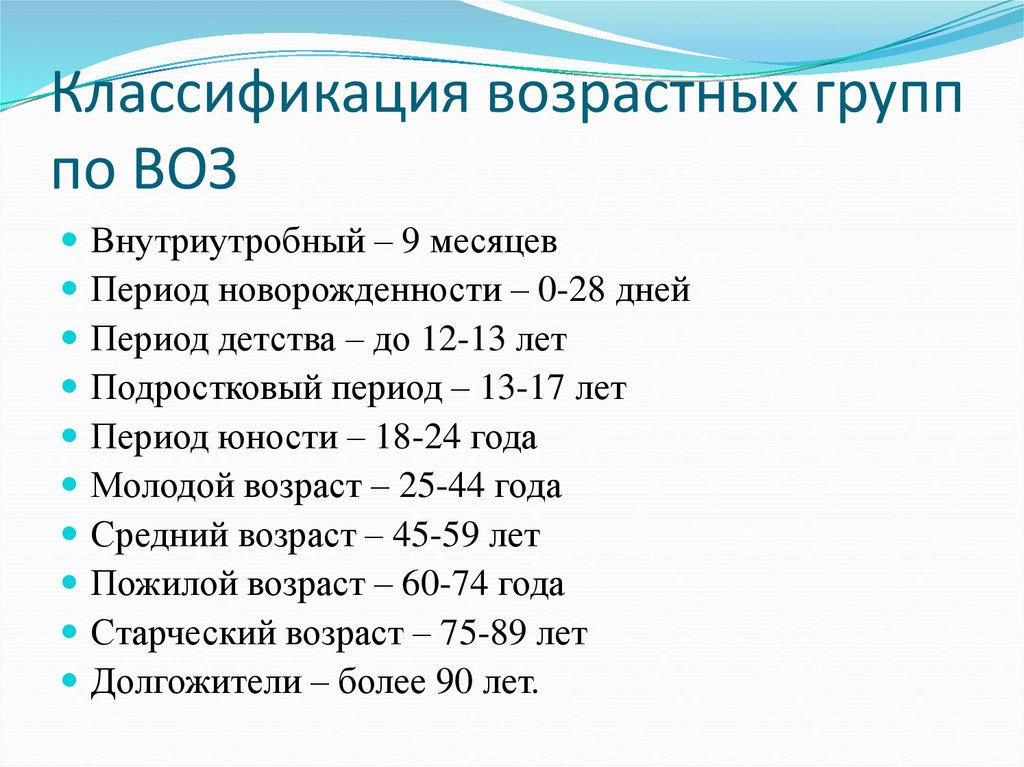

In [ ]:
def get_age(x):
  if x < 14:
    return "0 - Выброс, < 14"
  elif x < 18:
    return "1 - Подростковый, 13-17"
  elif x < 25:
    return "2 - Юный, "
  elif x < 45:
    return "3 - Молодой, 25-44"
  elif x < 60:
    return "4 - Средний, 45-59"
  elif x < 75:
    return "5 - Пожилой, 60-74"
  elif x < 90:
    return "6 - Старческий, 75-89"
  elif x > 90:
    return "7 - Долгожители, > 90"
  else:
    return "Отсутствует"

df["age_number"]  = df["age"]
df["age"]  = df["age"].apply(get_age)

In [ ]:
df[df["age"] == "7 - Долгожители, > 90"].age_number

# Предсказания

### Категориальные признаки 2

In [ ]:
irrelevant_columns = ['Столбец2', 'Столбец1', 'For FA', 'id', 'time_spent']

df = df.drop(columns=irrelevant_columns)

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols]

In [ ]:
for col in cat_cols:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)

In [ ]:
#ординальные
qualification_map = {'Нет':0, 'Первая':1, 'Вторая':2, 'Высшая':3}


income_level_map = {
    'Не хватает денег даже на еду':0,
    'Денег хватает на еду, но покупка одежды и оплата коммунальных услуг вызывает затруднения':1,
    'Денег хватает на еду и одежду, но покупка бытовой техники вызывает затруднения':2,
    'Денег хватает на одежду, еду и бытовую технику, но покупка автомобиля, квартиры или дачи вызывает затруднения':3,
    'Средств хватает чтобы купить все, что нужно':4
}

academic_degree_map = {'Нет':0, 'Кандидат наук':1, 'Доктор наук':2}

home_duty_map = {'Нет':0, 'Да':1}

change_hours_numb_map = {
    'Готов(а) ощутимо уменьшить':0,
    'Готов(а) слегка уменьшить':1,
    'Не готов(а)':2,
    'Готов(а) слегка увеличить':3,
    'Готов(а) ощутимо увеличить':4
}

expectation_prof_map = {
    'Определенно не оправдались':0,
    'Скорее не оправдались':1,
    'Скорее оправдались':2,
    'Определенно оправдались':3
}

schedule_map = {
    'Сменный график работы - ночь': 0,
    'Сменный график работы - день или вечер': 1,
    'Сменный график работы - сутки через трое': 2,
    'Пятидневная рабочая неделя': 3,
    'Шестидневная рабочая неделя': 4,
    'Другой': 5
}

burnout1_desc_map = {'Нет риска':0, 'Риск выгорания':1, 'Очень высокий риск выгорания':2}

org_type_map = { #по размеру
    'МИАЦ и ОИВ': 5,
    'Областная': 4,
    'Городская': 3,
    'СМП': 3,
    'Районная': 2,
    'Образование': 1,
    'Другие': 0,
    '-': 0
}

df['qualification'] = df['qualification'].map(qualification_map)
df['income_level'] = df['income_level'].map(income_level_map)
df['academic_degree'] = df['academic_degree'].map(academic_degree_map)
df['home_duty'] = df['home_duty'].map(home_duty_map)
df['change_hours_numb'] = df['change_hours_numb'].map(change_hours_numb_map)
df['expectation_prof'] = df['expectation_prof'].map(expectation_prof_map)
df['burnout1_desc'] = df['burnout1_desc'].map(burnout1_desc_map)
df['schedule'] = df['schedule'].map(schedule_map)
df['org_type'] = df['org_type'].map(org_type_map)

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols]

In [ ]:
num_cols = df.select_dtypes(exclude=["object", "category"]).columns
df[num_cols]

In [ ]:
# автоматически кодирую
for col in cat_cols:
    df[col] = pd.factorize(df[col])[0]

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols].head(3)

##Самые важные признаки

In [ ]:
targets = ['burnout1_integral', 'burnout1_desc', 'burnout1_dist', 'burnout1_exh', 'burnout1_emt', 'burnout1_cog']

X = df.drop(columns=targets)
y = df['burnout1_desc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
train_pool = Pool(X_train, y_train)
valid_pool = Pool(X_valid, y_valid)


def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10), #регуляризация
        'border_count': trial.suggest_int('border_count', 32, 255), #гибкость модели
        'random_seed': 33,
        'loss_function': 'MultiClass',
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    preds = model.predict(valid_pool)
    f1 = f1_score(y_valid, preds, average='weighted')

    return -f1


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры:", study.best_params)
print("Лучший F1", -study.best_value)

best_params = study.best_params
best_params.update({'loss_function':'MultiClass', 'random_seed':33, 'verbose':100})

final_model = CatBoostClassifier(**best_params)
final_model.fit(Pool(X_train, y_train))

# предсказания
y_pred = final_model.predict(X_valid)

In [ ]:
study_best = study.best_params
study_best

In [ ]:
model = CatBoostClassifier(
    iterations=study_best['iterations'],
    depth=study_best['depth'],
    learning_rate=study_best['learning_rate'],
    l2_leaf_reg=study_best['l2_leaf_reg'],
    border_count=study_best['border_count'],
    loss_function='MultiClass',  # для многоклассовой классификации
    verbose=100,
    random_seed=33
)

test_pool = Pool(X_test, y_test)
model.fit(train_pool)

preds = model.predict(test_pool)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, preds, digits=3)
print(report)

In [ ]:
importances = model.get_feature_importance()
feat_imp = pd.Series(importances, index=X_train.columns)

feat_imp.sort_values(ascending=False).head(15)

### Предсказание выгорания

###Демографические признаки

In [ ]:
#убираю составляющие шкалы
targets = ['burnout1_integral', 'burnout1_desc', 'burnout1_dist', 'burnout1_exh', 'burnout1_emt', 'burnout1_cog']
relevant = ['Регион', 'employment', 'employment2',
       'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper',
       'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
       'condition_org', 'income_level', 'academic_degree', 'home_duty',
       'expectation_prof', 'schedule','employment3', 'Organisation']

X = df[relevant]
y = df['burnout1_integral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Классификация

### Демография + удовлетворенность условиями работы

In [ ]:
features = ['Регион', 'Минуты', 'Часы', 'employment', 'employment2','shift_org_1', 'shift_reg_1', 'shift_spec_1', 'shift_prof_1', 'gender',
       'age', 'org_type', 'specialisation', 'qualification', 'exper',
       'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
       'condition_org', 'income_level', 'academic_degree', 'home_duty',
       'change_hours_numb', 'expectation_prof', 'schedule', 'comments',
       'Длина коммента', 'future_interest', 'future_prestige',
       'future_equipment', 'future_comfort', 'future_justice',
       'future_social_help', 'future_organisation', 'future_selfgrowth',
       'future_colleagues', 'future_leader', 'future_corpprocess',
       'future_information', 'future_schedule', 'future_riskinformation',
       'future_riskinformation2', 'future_patients', 'future_region',
       'future_region_healthcare', 'employment3', 'Organisation', 'age_number']

y = df['burnout1_desc']
X = df[features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
plt.hist(y_train, bins=3, rwidth=0.8)

plt.title("Распределение y_train")
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
train_pool = Pool(X_train, y_train)
valid_pool = Pool(X_valid, y_valid)


def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10), #регуляризация
        'border_count': trial.suggest_int('border_count', 32, 255), #гибкость модели
        'random_seed': 33,
        'loss_function': 'MultiClass',
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    preds = model.predict(valid_pool)
    f1 = f1_score(y_valid, preds, average='weighted')

    return -f1


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры:", study.best_params)
print("Лучший F1", -study.best_value)

best_params = study.best_params
best_params.update({'loss_function':'MultiClass', 'random_seed':33, 'verbose':100})

final_model = CatBoostClassifier(**best_params)
final_model.fit(Pool(X_train, y_train))

# предсказания
y_pred = final_model.predict(X_valid)

In [ ]:
study_best = study.best_params
study_best

In [ ]:
model = CatBoostClassifier(
    iterations=study_best['iterations'],
    depth=study_best['depth'],
    learning_rate=study_best['learning_rate'],
    l2_leaf_reg=study_best['l2_leaf_reg'],
    border_count=study_best['border_count'],
    loss_function='MultiClass',  # для многоклассовой классификации
    verbose=100,
    random_seed=33
)

test_pool = Pool(X_test, y_test)
model.fit(train_pool)

preds = model.predict(test_pool)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, preds, digits=3)
print(report)

In [ ]:
importances = model.get_feature_importance()
feat_imp = pd.Series(importances, index=X_train.columns)

feat_imp.sort_values(ascending=False).head(15)

### Только демографические данные

In [ ]:
targets = ['burnout1_integral', 'burnout1_desc', 'burnout1_dist', 'burnout1_exh', 'burnout1_emt', 'burnout1_cog']
relevant = ['Регион', 'employment', 'employment2',
       'gender', 'age', 'org_type', 'specialisation', 'qualification', 'exper',
       'exper_org', 'exper_reg', 'wage_rate', 'avr_work_hours',
       'condition_org', 'income_level', 'academic_degree', 'home_duty',
       'expectation_prof', 'schedule','employment3', 'Organisation']

y = df['burnout1_desc']
X = df[relevant]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
train_pool = Pool(X_train, y_train)
valid_pool = Pool(X_valid, y_valid)


def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10), #регуляризация
        'border_count': trial.suggest_int('border_count', 32, 255), #гибкость модели
        'random_seed': 33,
        'loss_function': 'MultiClass',
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

    preds = model.predict(valid_pool)
    f1 = f1_score(y_valid, preds, average='weighted')

    return -f1


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры:", study.best_params)
print("Лучший F1", -study.best_value)

best_params = study.best_params
best_params.update({'loss_function':'MultiClass', 'random_seed':33, 'verbose':100})

final_model = CatBoostClassifier(**best_params)
final_model.fit(Pool(X_train, y_train))

# предсказания
y_pred = final_model.predict(X_valid)

In [ ]:
study_best = study.best_params
study_best

In [ ]:
model = CatBoostClassifier(
    iterations=study_best['iterations'],
    depth=study_best['depth'],
    learning_rate=study_best['learning_rate'],
    l2_leaf_reg=study_best['l2_leaf_reg'],
    border_count=study_best['border_count'],
    loss_function='MultiClass',  # для многоклассовой классификации
    verbose=100,
    random_seed=33
)

test_pool = Pool(X_test, y_test)
model.fit(train_pool)

preds = model.predict(test_pool)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, preds, digits=3)
print(report)

In [ ]:
importances = model.get_feature_importance()
feat_imp = pd.Series(importances, index=X_train.columns)

feat_imp.sort_values(ascending=False).head(15)